# 调查问卷可视化

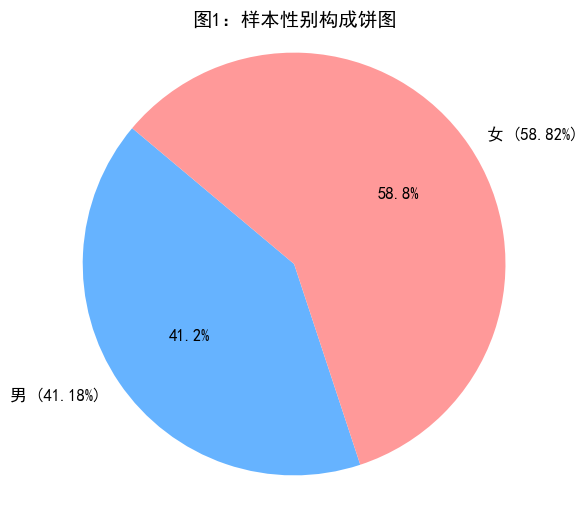

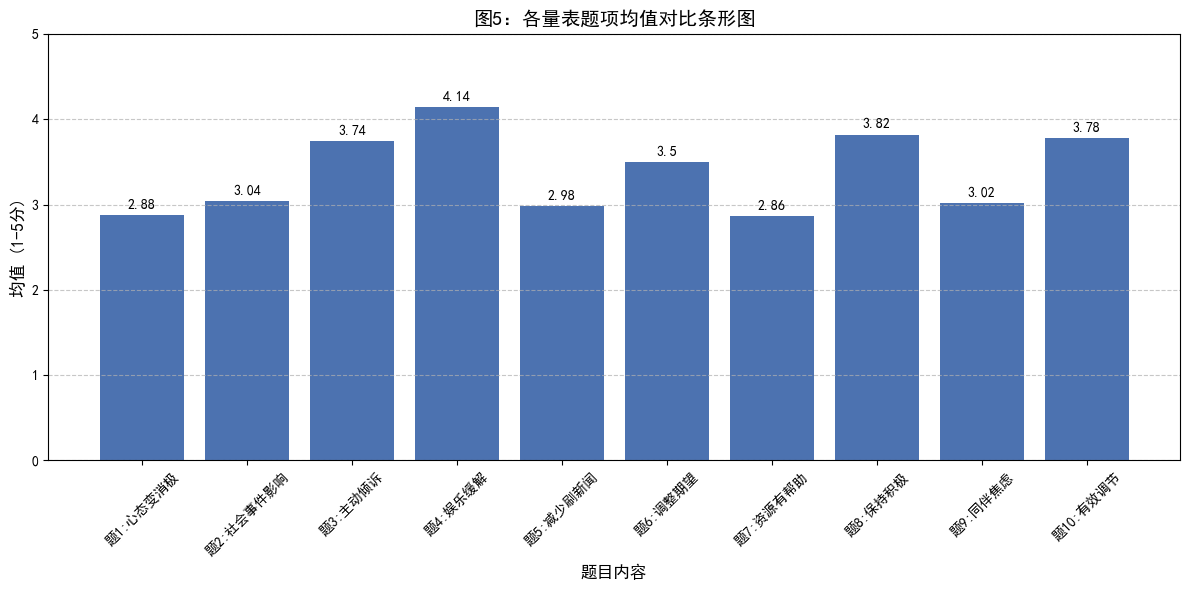

In [1]:
import matplotlib.pyplot as plt

# 设置中文字体（防止乱码）
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# --- 图1：样本性别构成饼图 ---
def plot_gender_pie():
    labels = ['男 (41.18%)', '女 (58.82%)']
    sizes = [41.18, 58.82]
    colors = ['#66b3ff', '#ff9999']
    
    plt.figure(figsize=(6, 6))
    plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140, textprops={'fontsize': 12})
    plt.title('图1：样本性别构成饼图', fontsize=14)
    plt.axis('equal')  # 保证是正圆
    plt.show()

# --- 图5：各量表题项均值对比条形图 ---
def plot_item_means_bar():
    # 数据提取自文档
    questions = ['题1:心态变消极', '题2:社会事件影响', '题3:主动倾诉', '题4:娱乐缓解', '题5:减少刷新闻', 
                 '题6:调整期望', '题7:资源有帮助', '题8:保持积极', '题9:同伴焦虑', '题10:有效调节']
    means = [2.88, 3.04, 3.74, 4.14, 2.98, 3.50, 2.86, 3.82, 3.02, 3.78]
    
    plt.figure(figsize=(12, 6))
    bars = plt.bar(questions, means, color='#4c72b0')
    
    # 添加数值标签
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.05, round(yval, 2), ha='center', va='bottom', fontsize=10)
        
    plt.ylim(0, 5) # 设置Y轴范围0-5
    plt.title('图5：各量表题项均值对比条形图', fontsize=14)
    plt.xlabel('题目内容', fontsize=12)
    plt.ylabel('均值 (1-5分)', fontsize=12)
    plt.xticks(rotation=45) # 旋转X轴标签防止重叠
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# 运行绘图函数
plot_gender_pie()
plot_item_means_bar()

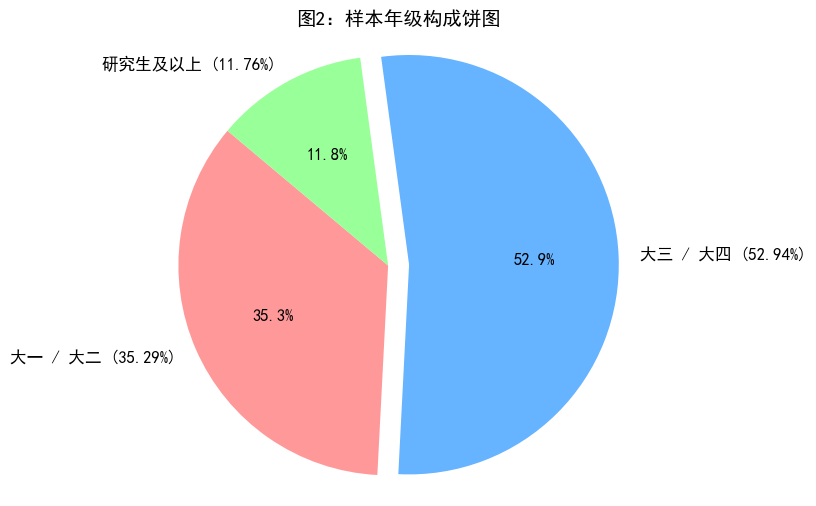

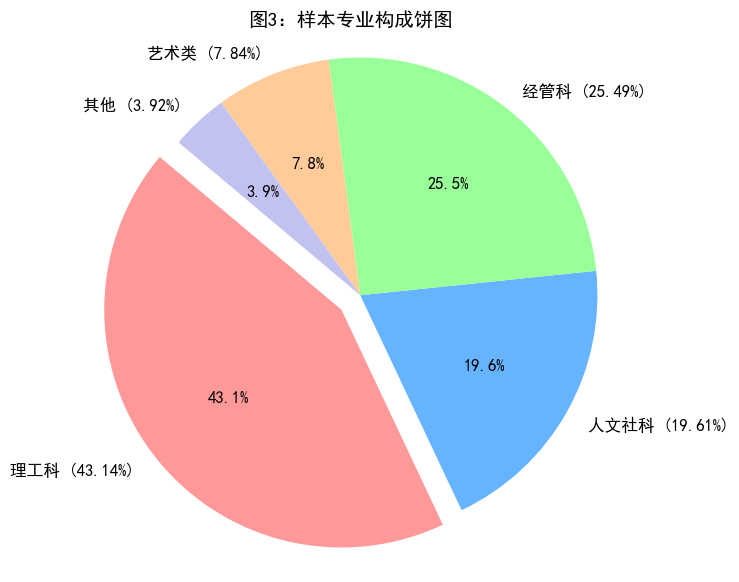

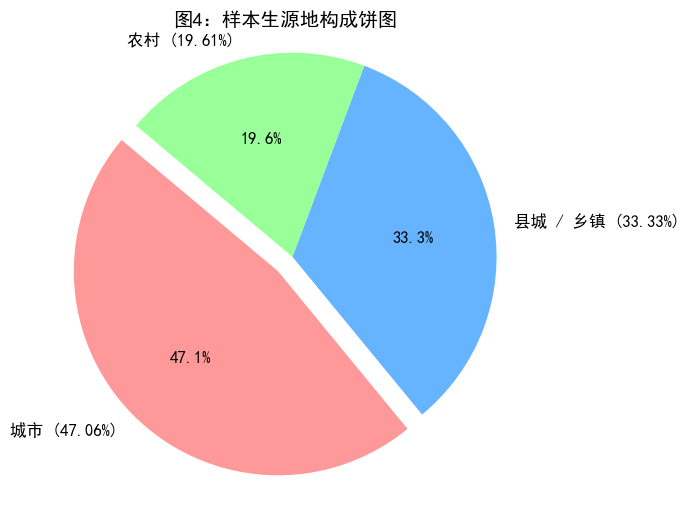

In [2]:
# --- 图2：样本年级构成饼图 ---
def plot_grade_pie():
    labels = ['大一 / 大二 (35.29%)', '大三 / 大四 (52.94%)', '研究生及以上 (11.76%)']
    sizes = [35.29, 52.94, 11.76]
    colors = ['#ff9999','#66b3ff','#99ff99']
    # 突出显示占比最大的部分（大三/大四）
    explode = (0, 0.1, 0) 
    
    plt.figure(figsize=(6, 6))
    plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140, textprops={'fontsize': 12})
    plt.title('图2：样本年级构成饼图', fontsize=14)
    plt.axis('equal')
    plt.show()

# --- 图3：样本专业构成饼图 ---
def plot_major_pie():
    labels = ['理工科 (43.14%)', '人文社科 (19.61%)', '经管科 (25.49%)', '艺术类 (7.84%)', '其他 (3.92%)']
    sizes = [43.14, 19.61, 25.49, 7.84, 3.92]
    colors = ['#ff9999','#66b3ff','#99ff99', '#ffcc99', '#c2c2f0']
    # 突出显示占比最大的部分（理工科）
    explode = (0.1, 0, 0, 0, 0) 
    
    plt.figure(figsize=(7, 7))
    plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140, textprops={'fontsize': 12})
    plt.title('图3：样本专业构成饼图', fontsize=14)
    plt.axis('equal')
    plt.show()

# --- 图4：样本生源地构成饼图 ---
def plot_origin_pie():
    labels = ['城市 (47.06%)', '县城 / 乡镇 (33.33%)', '农村 (19.61%)']
    sizes = [47.06, 33.33, 19.61]
    colors = ['#ff9999','#66b3ff','#99ff99']
    # 突出显示占比最大的部分（城市）
    explode = (0.1, 0, 0) 
    
    plt.figure(figsize=(6, 6))
    plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140, textprops={'fontsize': 12})
    plt.title('图4：样本生源地构成饼图', fontsize=14)
    plt.axis('equal')
    plt.show()

# 运行新生成的绘图函数
plot_grade_pie()
plot_major_pie()
plot_origin_pie()

# Echarts示例转pyecharts

In [1]:
from pyecharts_exporter import display_chart

In [7]:
from pyecharts import options as opts
from pyecharts.charts import HeatMap
from pyecharts.commons.utils import JsCode
import json

# ==================== 数据准备 ====================
# 颜色配置
color = {
    'green': '#2D9A69',
    'purple': '#7D568F',
    'blue': '#3A8DAB',
    'yellow': '#E0A433',
    'greenLighter': '#10CA77',
    'purpleLighter': '#9253AF',
    'blueLighter': '#26A9D9',
    'yellowLighter': '#F4AC24',
    'greenDarker': '#0FB369',
    'purpleDarker': '#854AA0',
    'blueDarker': '#2298C3',
    'yellowDarker': '#F2A30D'
}

# MBTI 类型列表
mbti = [
    'ENFJ', 'ENFP', 'ENTJ', 'ENTP',
    'ESFJ', 'ESFP', 'ESTJ', 'ESTP',
    'INFJ', 'INFP', 'INTJ', 'INTP',
    'ISFJ', 'ISFP', 'ISTJ', 'ISTP'
]

# 原始数据
original_data = [
    ['ENFJ', 'ENFJ', 0.86], ['ENFJ', 'ENFP', 0.91], ['ENFJ', 'ENTJ', 0.42],
    ['ENFJ', 'ENTP', 0.73], ['ENFJ', 'ESFJ', 0.64], ['ENFJ', 'ESFP', 0.8],
    ['ENFJ', 'ESTJ', 0.22], ['ENFJ', 'ESTP', 0.41], ['ENFJ', 'INFJ', 0.74],
    ['ENFJ', 'INFP', 0.73], ['ENFJ', 'INTJ', 0.16], ['ENFJ', 'INTP', 0.35],
    ['ENFJ', 'ISFJ', 0.3], ['ENFJ', 'ISFP', 0.4], ['ENFJ', 'ISTJ', 0.18],
    ['ENFJ', 'ISTP', 0.09], ['ENFP', 'ENFJ', 0.91], ['ENFP', 'ENFP', 0.97],
    ['ENFP', 'ENTJ', 0.37], ['ENFP', 'ENTP', 0.85], ['ENFP', 'ESFJ', 0.42],
    ['ENFP', 'ESFP', 0.93], ['ENFP', 'ESTJ', 0.27], ['ENFP', 'ESTP', 0.76],
    ['ENFP', 'INFJ', 0.51], ['ENFP', 'INFP', 0.73], ['ENFP', 'INTJ', 0.13],
    ['ENFP', 'INTP', 0.36], ['ENFP', 'ISFJ', 0.11], ['ENFP', 'ISFP', 0.49],
    ['ENFP', 'ISTJ', 0.04], ['ENFP', 'ISTP', 0.14], ['ENTJ', 'ENFJ', 0.42],
    ['ENTJ', 'ENFP', 0.37], ['ENTJ', 'ENTJ', 0.91], ['ENTJ', 'ENTP', 0.81],
    ['ENTJ', 'ESFJ', 0.53], ['ENTJ', 'ESFP', 0.51], ['ENTJ', 'ESTJ', 0.87],
    ['ENTJ', 'ESTP', 0.74], ['ENTJ', 'INFJ', 0.25], ['ENTJ', 'INFP', 0.13],
    ['ENTJ', 'INTJ', 0.46], ['ENTJ', 'INTP', 0.47], ['ENTJ', 'ISFJ', 0.29],
    ['ENTJ', 'ISFP', 0.06], ['ENTJ', 'ISTJ', 0.66], ['ENTJ', 'ISTP', 0.41],
    ['ENTP', 'ENFJ', 0.73], ['ENTP', 'ENFP', 0.64], ['ENTP', 'ENTJ', 0.81],
    ['ENTP', 'ENTP', 0.94], ['ENTP', 'ESFJ', 0.32], ['ENTP', 'ESFP', 0.87],
    ['ENTP', 'ESTJ', 0.7], ['ENTP', 'ESTP', 0.92], ['ENTP', 'INFJ', 0.11],
    ['ENTP', 'INFP', 0.35], ['ENTP', 'INTJ', 0.22], ['ENTP', 'INTP', 0.51],
    ['ENTP', 'ISFJ', 0.05], ['ENTP', 'ISFP', 0.14], ['ENTP', 'ISTJ', 0.11],
    ['ENTP', 'ISTP', 0.35], ['ESFJ', 'ESFJ', 0.94], ['ESFJ', 'ESFP', 0.4],
    ['ESFJ', 'ESTJ', 0.77], ['ESFJ', 'ESTP', 0.37], ['ESFJ', 'INFJ', 0.74],
    ['ESFJ', 'INFP', 0.17], ['ESFJ', 'INTJ', 0.32], ['ESFJ', 'INTP', 0.05],
    ['ESFJ', 'ISFJ', 0.79], ['ESFJ', 'ISFP', 0.57], ['ESFJ', 'ISTJ', 0.71],
    ['ESFJ', 'ISTP', 0.19], ['ESFP', 'ESFP', 0.7], ['ESFP', 'ESTJ', 0.39],
    ['ESFP', 'ESTP', 0.75], ['ESFP', 'INFJ', 0.43], ['ESFP', 'INFP', 0.58],
    ['ESFP', 'INTJ', 0.22], ['ESFP', 'INTP', 0.39], ['ESFP', 'ISFJ', 0.12],
    ['ESFP', 'ISFP', 0.58], ['ESFP', 'ISTJ', 0.08], ['ESFP', 'ISTP', 0.26],
    ['ESTJ', 'ESTJ', 0.96], ['ESTJ', 'ESTP', 0.78], ['ESTJ', 'INFJ', 0.14],
    ['ESTJ', 'INFP', 0.03], ['ESTJ', 'INTJ', 0.33], ['ESTJ', 'INTP', 0.22],
    ['ESTJ', 'ISFJ', 0.48], ['ESTJ', 'ISFP', 0.22], ['ESTJ', 'ISTJ', 0.79],
    ['ESTJ', 'ISTP', 0.55], ['ESTP', 'ESTP', 0.95], ['ESTP', 'INFJ', 0.05],
    ['ESTP', 'INFP', 0.24], ['ESTP', 'INTJ', 0.17], ['ESTP', 'INTP', 0.39],
    ['ESTP', 'ISFJ', 0.12], ['ESTP', 'ISFP', 0.43], ['ESTP', 'ISTJ', 0.2],
    ['ESTP', 'ISTP', 0.62], ['INFJ', 'INFJ', 0.95], ['INFJ', 'INFP', 0.85],
    ['INFJ', 'INTJ', 0.65], ['INFJ', 'INTP', 0.5], ['INFJ', 'ISFJ', 0.85],
    ['INFJ', 'ISFP', 0.58], ['INFJ', 'ISTJ', 0.53], ['INFJ', 'ISTP', 0.23],
    ['INFP', 'INFP', 0.97], ['INFP', 'INTJ', 0.7], ['INFP', 'INTP', 0.84],
    ['INFP', 'ISFJ', 0.46], ['INFP', 'ISFP', 0.78], ['INFP', 'ISTJ', 0.21],
    ['INFP', 'ISTP', 0.49], ['INTJ', 'INTJ', 0.86], ['INTJ', 'INTP', 0.89],
    ['INTJ', 'ISFJ', 0.79], ['INTJ', 'ISFP', 0.45], ['INTJ', 'ISTJ', 0.85],
    ['INTJ', 'ISTP', 0.78], ['INTP', 'INTP', 0.96], ['INTP', 'ISFJ', 0.38],
    ['INTP', 'ISFP', 0.43], ['INTP', 'ISTJ', 0.51], ['INTP', 'ISTP', 0.81],
    ['ISFJ', 'ISFJ', 0.95], ['ISFJ', 'ISFP', 0.76], ['ISFJ', 'ISTJ', 0.93],
    ['ISFJ', 'ISTP', 0.62], ['ISFP', 'ISFP', 0.97], ['ISFP', 'ISTJ', 0.47],
    ['ISFP', 'ISTP', 0.76], ['ISTJ', 'ISTJ', 0.96], ['ISTJ', 'ISTP', 0.78],
    ['ISTP', 'ISTP', 0.96]
]

# 将 Python 数据转换为 JSON
mbti_json = json.dumps(mbti)
color_json = json.dumps(color)
original_data_json = json.dumps(original_data)

# ==================== 创建图表 ====================
chart = HeatMap(init_opts=opts.InitOpts(
    width="100%", 
    height="900px",
    bg_color="#F0F7F9",
    animation_opts=opts.AnimationOpts(animation=False)
))

# 添加空数据（实际数据将通过 JavaScript 注入）
chart.add_xaxis(xaxis_data=mbti)
chart.add_yaxis(
    series_name="兼容性",
    yaxis_data=mbti,
    value=[[0, 0, 0]],  # 占位数据
    label_opts=opts.LabelOpts(is_show=False),
)

# 设置全局选项
chart.set_global_opts(
    title_opts=opts.TitleOpts(
        title="MBTI Partner Compatibility",
        subtitle="Data from: https://www.personalitydata.org/16-types/enfj-relationships#partner-matrix",
        title_link="https://www.personalitydata.org/16-types/enfj-relationships#partner-matrix",
        pos_left="center",
        pos_top="5px",
        title_textstyle_opts=opts.TextStyleOpts(
            font_size=20, 
            color="#57576A", 
            font_family="Ubuntu Condensed, sans-serif"
        ),
    ),
    tooltip_opts=opts.TooltipOpts(is_show=False),
    visualmap_opts=opts.VisualMapOpts(
        min_=0,
        max_=1,
        dimension=2,
        is_calculable=True,
        orient="horizontal",
        pos_top="5px",
        pos_left="center",
        range_opacity=[0, 1],
        is_show=False
    ),
)

# ==================== 完整的 JavaScript 逻辑 ====================
custom_js = f"""
// 数据定义
const mbti = {mbti_json};
const color = {color_json};
const originalData = {original_data_json};

// 获取颜色函数
const getColor = (mbti, lightness = 0) => {{
    if (mbti.indexOf('NF') >= 0) {{
        return lightness < 0 ? color.greenLighter : lightness > 0 ? color.greenDarker : color.green;
    }}
    if (mbti.indexOf('NT') >= 0) {{
        return lightness < 0 ? color.purpleLighter : lightness > 0 ? color.purpleDarker : color.purple;
    }}
    if (mbti.indexOf('S') >= 0 && mbti.indexOf('J') >= 0) {{
        return lightness < 0 ? color.blueLighter : lightness > 0 ? color.blueDarker : color.blue;
    }}
    if (mbti.indexOf('S') >= 0 && mbti.indexOf('P') >= 0) {{
        return lightness < 0 ? color.yellowLighter : lightness > 0 ? color.yellowDarker : color.yellow;
    }}
    return '#000000';
}};

// 工具函数：获取组别
const getGroup = (mbti) => {{
    if (mbti.indexOf('NF') >= 0) return 'NF';
    if (mbti.indexOf('NT') >= 0) return 'NT';
    if (mbti[1] === 'S' && mbti[3] === 'J') return 'SJ';
    if (mbti[1] === 'S' && mbti[3] === 'P') return 'SP';
    return '';
}};

// 中位数函数
function median(arr) {{
    const sorted = arr.slice().sort((a, b) => a - b);
    const mid = Math.floor(sorted.length / 2);
    if (sorted.length % 2 === 0) {{
        return (sorted[mid - 1] + sorted[mid]) / 2;
    }} else {{
        return sorted[mid];
    }}
}}

// 构建数据映射
const dataMap = new Map();
for (const [a, b, v] of originalData) {{
    dataMap.set(`${{a}}-${{b}}`, v);
}}

// 准备详细热力图数据（带装饰图案和颜色）
const decalSize = 1;
const heatmapData = [];
const scatterData = [];

for (const a of mbti) {{
    for (const b of mbti) {{
        const key = `${{a}}-${{b}}`;
        const altKey = `${{b}}-${{a}}`;
        let value;
        if (dataMap.has(key)) {{
            value = [a, b, dataMap.get(key)];
        }} else if (dataMap.has(altKey)) {{
            value = [a, b, dataMap.get(altKey)];
        }} else {{
            value = [a, b, 0];
        }}
        
        heatmapData.push({{
            value: value,
            itemStyle: {{
                decal: {{
                    shape: 'circle',
                    symbolSize: 1,
                    color: getColor(a, 1),
                    backgroundColor: getColor(b, 1),
                    dashArrayX: [
                        [decalSize, decalSize],
                        [0, decalSize, decalSize, 0]
                    ],
                    dashArrayY: [decalSize, 0]
                }},
                borderColor: getColor(b),
                borderWidth: 0
            }}
        }});
        
        scatterData.push({{
            value: value,
            label: {{
                color: value[2] < 0.2 ? getColor(b) : '#fff',
                opacity: value[2] < 0.15 ? 0.6 : 1
            }}
        }});
    }}
}}

// 准备分组数据（带颜色）
const fontSize = {{
    group: window.innerHeight > 700 ? 24 : 16,
    item: window.innerHeight > 700 ? 13 : 11,
    value: window.innerHeight > 700 ? 15 : 12
}};

const groupRawData = {{}};
for (let i = 0; i < originalData.length; ++i) {{
    const [a, b, v] = originalData[i];
    const groupA = getGroup(a);
    const groupB = getGroup(b);
    const key = groupA > groupB ? `${{groupA}}-${{groupB}}` : `${{groupB}}-${{groupA}}`;
    if (groupRawData[key]) {{
        groupRawData[key].push(v);
    }} else {{
        groupRawData[key] = [v];
    }}
}}

const groupData = [];
for (const key in groupRawData) {{
    if (groupRawData.hasOwnProperty(key)) {{
        const [a, b] = key.split('-');
        const v = median(groupRawData[key]);
        const colorA = getColor(a, 1);
        const colorB = getColor(b, 1);
        
        // 构建标签样式
        const label = {{
            show: true,
            color: v < 0.2 ? getColor(b) : '#fff',
            fontSize: fontSize.value,
            fontWeight: 'bold',
            opacity: v < 0.15 ? 0.6 : 1,
            formatter: function(params) {{
                return `${{Math.round(params.value[2] * 100)}}%`;
            }}
        }};
        
        // 构建装饰图案样式
        const decalSize = 3;
        const itemStyle = {{
            decal: {{
                shape: 'circle',
                symbolSize: 1,
                color: colorA,
                backgroundColor: colorB,
                dashArrayX: [
                    [decalSize, decalSize],
                    [0, decalSize, decalSize, 0]
                ],
                dashArrayY: [decalSize, 0]
            }},
            borderColor: getColor(b),
            borderWidth: 0
        }};
        
        groupData.push({{
            value: [a, b, v],
            label: label,
            itemStyle: itemStyle
        }});
        
        if (a !== b) {{
            groupData.push({{
                value: [b, a, v],
                label: label,
                itemStyle: itemStyle
            }});
        }}
    }}
}}

// 生成轴数据
const colorMap = {{
    NF: color.green,
    NT: color.purple,
    SJ: color.blue,
    SP: color.yellow
}};

const groupMembers = {{
    NF: ['INFJ', 'INFP', 'ENFJ', 'ENFP'],
    NT: ['INTJ', 'INTP', 'ENTJ', 'ENTP'],
    SJ: ['ISFJ', 'ISTJ', 'ESFJ', 'ESTJ'],
    SP: ['ISFP', 'ISTP', 'ESFP', 'ESTP']
}};

const generateGroup = (groupName) => {{
    return {{
        value: groupName,
        label: {{
            color: colorMap[groupName],
            fontSize: fontSize.group,
            fontWeight: 'bolder',
            padding: 0
        }},
        children: groupMembers[groupName].map((mbti) => ({{
            value: mbti,
            label: {{
                color: colorMap[groupName],
                fontSize: fontSize.item,
                fontWeight: 'bold'
            }}
        }}))
    }};
}};

const xData = ['NF', 'NT', 'SJ', 'SP'].map(generateGroup);
const yData = ['NF', 'NT', 'SJ', 'SP'].map(generateGroup);

// 详细视图系列
const detailSeries = [
    {{
        id: 'detail-heatmap',
        type: 'heatmap',
        coordinateSystem: 'matrix',
        data: heatmapData,
        label: {{
            show: false
        }},
        emphasis: {{
            itemStyle: {{
                borderWidth: 5
            }}
        }}
    }},
    {{
        id: 'detail-scatter',
        type: 'scatter',
        coordinateSystem: 'matrix',
        symbolSize: 0,
        data: scatterData,
        color: '#fff',
        label: {{
            show: true,
            formatter: function(params) {{
                return Math.round(params.value[2] * 100) + '%';
            }},
            fontWeight: 'bold',
            color: 'inherit'
        }},
        silent: true
    }}
];

// 分组视图系列
const groupSeries = [
    {{
        id: 'summary-heatmap',
        type: 'heatmap',
        coordinateSystem: 'matrix',
        data: groupData,
        label: {{
            show: true
        }}
    }}
];

// 计算尺寸
const size = Math.round(Math.min(window.innerWidth, window.innerHeight) * 0.9);

// 构建完整的 option
const fullOption = {{
    backgroundColor: '#F0F7F9',
    textStyle: {{
        fontFamily: 'Ubuntu Condensed, sans-serif'
    }},
    title: {{
        text: 'MBTI Partner Compatibility',
        subtext: 'Data from: https://www.personalitydata.org/16-types/enfj-relationships#partner-matrix',
        sublink: 'https://www.personalitydata.org/16-types/enfj-relationships#partner-matrix',
        left: 'center',
        top: 5,
        textStyle: {{
            fontSize: 20,
            color: '#57576A'
        }},
        itemGap: 5
    }},
    tooltip: {{
        formatter: function(params) {{
            return '<span style="color:' + getColor(params.value[1]) + ';font-weight:bold">' + 
                   params.value[1] + '</span> / ' +
                   '<span style="color:' + getColor(params.value[0]) + ';font-weight:bold">' + 
                   params.value[0] + '</span> : ' +
                   Math.round(params.value[2] * 100) + '%';
        }},
        borderColor: '#eee',
        padding: [2, 8]
    }},
    matrix: {{
        x: {{
            data: xData,
            itemStyle: {{
                borderColor: 'transparent',
                borderWidth: 0
            }},
            dividerLineStyle: {{
                width: 0
            }},
            label: {{
                fontFamily: 'Ubuntu Condensed, sans-serif'
            }},
            levels: [
                {{ levelSize: 25 }},
                {{ levelSize: 30 }}
            ]
        }},
        y: {{
            data: yData,
            itemStyle: {{
                borderColor: 'transparent',
                borderWidth: 0
            }},
            dividerLineStyle: {{
                width: 0
            }},
            label: {{
                fontFamily: 'Ubuntu Condensed, sans-serif'
            }}
        }},
        body: {{
            itemStyle: {{
                borderWidth: 0
            }},
            label: {{
                fontFamily: 'Ubuntu Condensed, sans-serif'
            }}
        }},
        width: size,
        height: size,
        left: (window.innerWidth - size) / 2,
        top: 50,
        backgroundStyle: {{
            color: 'transparent',
            borderColor: 'transparent',
            borderWidth: 0
        }}
    }},
    visualMap: [
        {{
            type: 'continuous',
            min: 0,
            max: 1,
            dimension: 2,
            calculable: true,
            orient: 'horizontal',
            top: 5,
            left: 'center',
            inRange: {{
                opacity: [0, 1]
            }},
            seriesIndex: [0, 2],
            show: false
        }}
    ],
    series: detailSeries,
    aria: {{
        enabled: true,
        decal: {{
            show: true
        }}
    }},
    animation: 0
}};

// 等待图表初始化完成后应用自定义配置
setTimeout(function() {{
    // 获取 ECharts 实例
    var chartDom = document.querySelector('.chart-container');
    var chartInstance = echarts.getInstanceByDom(chartDom);
    
    if (chartInstance) {{
        // 应用完整配置
        chartInstance.setOption(fullOption, true);
        
        // 添加点击事件处理
        var isGroup = false;
        chartInstance.on('click', function() {{
            isGroup = !isGroup;
            fullOption.series = isGroup ? groupSeries : detailSeries;
            chartInstance.setOption(fullOption, true);
        }});
    }}
}}, 100);
"""

chart.add_js_funcs(custom_js)

# 渲染图表
#chart.render("mbti_compatibility_matrix.html")
#print("图表已生成: mbti_compatibility_matrix.html")

display_chart(chart)

In [ ]:
from pyecharts import options as opts
from pyecharts.charts import Pie
from pyecharts.commons.utils import JsCode

# ==================== 数据准备 ====================
# 内圈数据
inner_data = [
    {"value": 1548, "name": "Search Engine"},
    {"value": 775, "name": "Direct"},
    {"value": 679, "name": "Marketing"}
]

# 外圈数据
outer_data = [
    {"value": 1048, "name": "Baidu"},
    {"value": 335, "name": "Direct"},
    {"value": 310, "name": "Email"},
    {"value": 251, "name": "Google"},
    {"value": 234, "name": "Union Ads"},
    {"value": 147, "name": "Bing"},
    {"value": 135, "name": "Video Ads"},
    {"value": 102, "name": "Others"}
]

# ==================== 创建图表 ====================
pie = Pie(init_opts=opts.InitOpts(
    width="900px", 
    height="600px",
    bg_color="#fff"
))

# 富文本格式化函数
rich_formatter = """function(params) {
    return '{a|' + params.seriesName + '}{abg|}\\n{hr|}\\n  {b|' + 
           params.name + '：}' + params.value + '  {per|' + 
           params.percent + '%}  ';
}"""

# 添加内圈饼图
pie.add(
    series_name="Access From",
    data_pair=[(d["name"], d["value"]) for d in inner_data],
    radius=[0, "30%"],
    selected_mode="single",
    selected_offset=10,
    label_opts=opts.LabelOpts(
        position="inner",
        font_size=14
    ),
)

# 添加外圈饼图
pie.add(
    series_name="Access From",
    data_pair=[(d["name"], d["value"]) for d in outer_data],
    radius=["45%", "60%"],
    label_opts=opts.LabelOpts(
        formatter=JsCode(rich_formatter),
        background_color="#F6F8FC",
        border_color="#8C8D8E",
        border_width=1,
        border_radius=4,
        rich={
            "a": {
                "color": "#6E7079",
                "lineHeight": 22,
                "align": "center"
            },
            "hr": {
                "borderColor": "#8C8D8E",
                "width": "100%",
                "borderWidth": 1,
                "height": 0
            },
            "b": {
                "color": "#4C5058",
                "fontSize": 14,
                "fontWeight": "bold",
                "lineHeight": 33
            },
            "per": {
                "color": "#fff",
                "backgroundColor": "#4C5058",
                "padding": [3, 4],
                "borderRadius": 4
            }
        }
    )
)

# 设置全局选项
pie.set_global_opts(
    tooltip_opts=opts.TooltipOpts(
        trigger="item",
        formatter="{a} <br/>{b}: {c} ({d}%)"
    ),
    legend_opts=opts.LegendOpts(
        orient="horizontal",      # 水平排列
        pos_left="center",         # 水平居中
        pos_bottom="0px",          # 底部对齐
        item_gap=15,               # 图例项之间的间距
    )
)

# 通过 options 字典直接设置 labelLine
pie.options.get("series", [{}])[0].update({"labelLine": {"show": False}})
pie.options.get("series", [{}])[1].update({"labelLine": {"show": True, "length": 30}})

# 注入 JavaScript 来设置默认选中 Marketing
pie.add_js_funcs("""
    setTimeout(function() {
        var chartDom = document.querySelector('.chart-container');
        var chartInstance = echarts.getInstanceByDom(chartDom);
        if (chartInstance) {
            chartInstance.dispatchAction({
                type: 'pieSelect',
                seriesIndex: 0,
                name: 'Marketing'
            });
        }
    }, 200);
""")

# 渲染图表
#pie.render("nested_pie_chart.html")
#print("图表已生成: nested_pie_chart.html")

display_chart(pie)

In [15]:
!jupyter nbconvert --to html 1.ipynb

[NbConvertApp] Converting notebook 1.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 5 image(s).
[NbConvertApp] Writing 661281 bytes to 1.html
